# Model 1: Future Potential Prediction

## Problem Type: Classification

### Target:

- future_potential

### Output:

- Low
- Medium
- High
- Elite

# Model 2: Auction Value Prediction

## Problem Type: Regression

### Target:

- auction_value_cr

### Output:

- Predicted Auction Value

## Step 1 : import libraries

In [49]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

## Step 2 : Load dataset

In [123]:
df = pd.read_csv("players_featured.csv")

df.head()

,player_id,age,role,matches,runs,batting_average,strike_rate,fifties,hundreds,wickets,...,catches,fitness_score,raw_score,talent_score,future_potential,auction_value_cr,batting_impact,bowling_impact,experience_score,consistency_score
0,1,21,Batter,199,5253,42.35,129.77,16,18,2,...,14,80,67.5165,31.46,Low,6.18,5495.7595,0.239234,4179,52
1,2,20,Bowler,69,1034,22.04,98.06,5,1,156,...,22,80,66.4690,29.48,Low,7.69,2161.2424,26.896552,1380,7
2,3,23,Wicketkeeper,97,4276,29.66,167.00,26,3,1,...,95,91,79.7900,54.73,Medium,8.39,4953.2200,0.132979,2231,32
3,4,26,Batter,196,6763,51.09,188.12,34,3,17,...,56,88,91.6910,77.28,High,12.93,9611.0508,2.370990,5096,40
4,5,24,Batter,21,4866,58.19,188.97,24,4,12,...,56,85,89.1245,72.42,High,11.72,10996.1643,1.687764,504,32


## Step 3 : Encode categorical Columns 

In [51]:
role_encoder = LabelEncoder()

df["role"] = role_encoder.fit_transform(
    df["role"]
)

## Encode Future Potential 

In [52]:
potential_encoder = LabelEncoder()

df["future_potential_encoded"] = (
    potential_encoder.fit_transform(
        df["future_potential"]
    )
)

In [53]:
print(
    dict(
        zip(
            potential_encoder.classes_,
            potential_encoder.transform(
                potential_encoder.classes_
            )
        )
    )
)

{'Elite': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2), 'Medium': np.int64(3)}


# MODEL 1: Future Potential Classificationm

## Step 4: Define Features

- Remove target columns.

In [54]:
X = df.drop(
    columns=[
        "player_id",
        "future_potential",
        "future_potential_encoded",
        "auction_value_cr",
        "talent_score",
        "raw_score"
    ]
)

y = df["future_potential_encoded"]

In [55]:
print(X.columns.tolist())

['age', 'role', 'matches', 'runs', 'batting_average', 'strike_rate', 'fifties', 'hundreds', 'wickets', 'economy', 'catches', 'fitness_score', 'batting_impact', 'bowling_impact', 'experience_score', 'consistency_score']


## Step 5 : Train - Test Splitm

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Step 6: Train Random Forest Classifier

In [57]:
clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

clf.fit(X_train, y_train)



RandomForestClassifier(n_estimators=200, random_state=42)

## Step 7 : Predictions

In [58]:
y_pred = clf.predict(X_test)

In [59]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67        16
           1       0.80      0.76      0.78       150
           2       0.93      0.76      0.84       145
           3       0.79      0.90      0.84       289

    accuracy                           0.82       600
   macro avg       0.88      0.73      0.78       600
weighted avg       0.83      0.82      0.82       600



In [60]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8216666666666667


## Step 8 : Evaluation

In [61]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.8216666666666667


## Classification Report 

In [62]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.50      0.67        16
           1       0.80      0.76      0.78       150
           2       0.93      0.76      0.84       145
           3       0.79      0.90      0.84       289

    accuracy                           0.82       600
   macro avg       0.88      0.73      0.78       600
weighted avg       0.83      0.82      0.82       600



## Confusion Matrix 

In [63]:
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

[[  8   8   0   0]
 [  0 114   0  36]
 [  0   0 110  35]
 [  0  20   8 261]]


# MODEL 2: Auction Value Prediction

## Step 9: Features & Target

In [87]:
X_reg = df.drop(
    columns=[
        "player_id",
        "future_potential",
        "future_potential_encoded",
        "auction_value_cr",
        "raw_score",
        "talent_score"
    ]
)

## Step 10 : Split Data

In [88]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

## Step 11 : Regressor

In [89]:
reg = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

reg.fit(X_train_reg, y_train_reg)

RandomForestRegressor(n_estimators=300, random_state=42)

## Step 12 : Predictions

In [90]:
y_pred_reg = reg.predict(
    X_test_reg
)

## Step 13 : Evaluation

# MAE

In [91]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y_test_reg,
    y_pred_reg
)

print("MAE:", mae)

MAE: 0.6386314999999998


# RMSE

In [92]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        y_pred_reg
    )
)

print("RMSE:", rmse)

RMSE: 0.8000649420481091


# R2 Score 

In [93]:
r2 = r2_score(
    y_test_reg,
    y_pred_reg
)

print("R2 Score:", r2)

R2 Score: 0.9205664546129978


In [94]:
print("R2:", r2)

R2: 0.9205664546129978


## Step 14: Feature Importance
- Classification

In [95]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": clf.feature_importances_
})

importance_df.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
13,bowling_impact,0.128080
12,batting_impact,0.110475
3,runs,0.099626
8,wickets,0.092347
5,strike_rate,0.088701
9,economy,0.076894
10,catches,0.076625
11,fitness_score,0.069027
4,batting_average,0.055913
15,consistency_score,0.036983


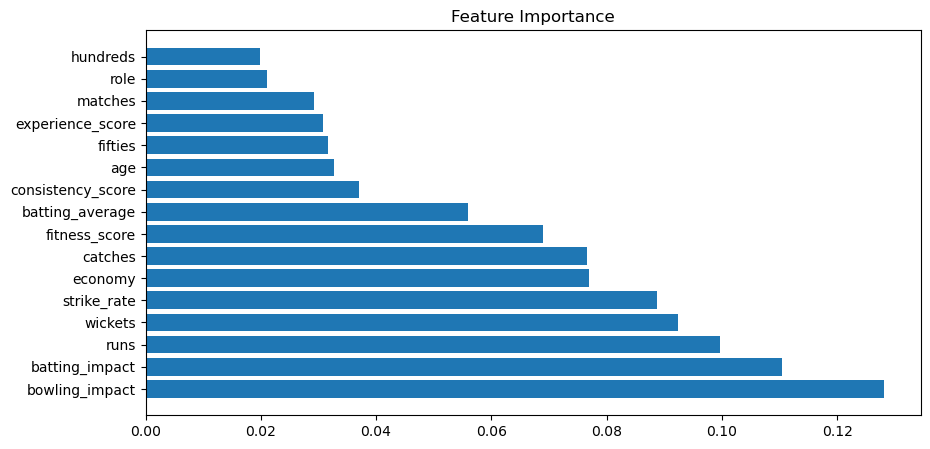

In [96]:
import matplotlib.pyplot as plt

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title("Feature Importance")
plt.show()

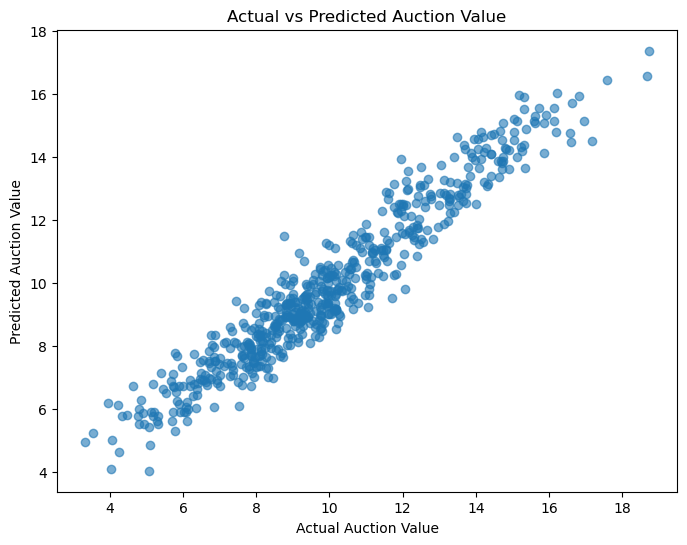

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_reg,
    y_pred_reg,
    alpha=0.6
)

plt.xlabel("Actual Auction Value")
plt.ylabel("Predicted Auction Value")

plt.title("Actual vs Predicted Auction Value")

plt.show()

# feature Importance

In [98]:
importance_df = pd.DataFrame({
    "Feature": X_reg.columns,
    "Importance": reg.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(
    importance_df.head(10)
)

            Feature  Importance
13   bowling_impact    0.310614
8           wickets    0.222861
12   batting_impact    0.193473
1              role    0.116284
10          catches    0.033298
3              runs    0.030177
11    fitness_score    0.025512
9           economy    0.018445
4   batting_average    0.013615
5       strike_rate    0.008288


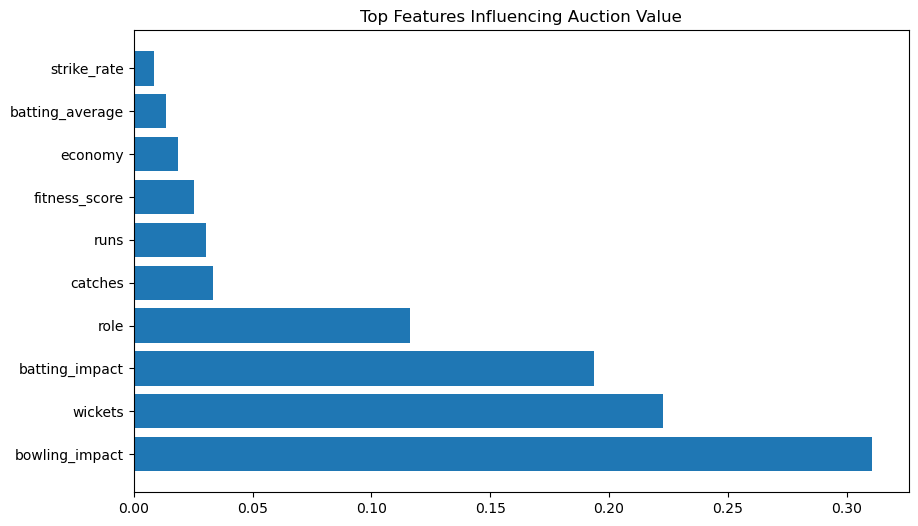

In [99]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"][:10],
    importance_df["Importance"][:10]
)

plt.title("Top Features Influencing Auction Value")

plt.show()

In [100]:
importance_df.head(10)

,Feature,Importance
13,bowling_impact,0.310614
8,wickets,0.222861
12,batting_impact,0.193473
1,role,0.116284
10,catches,0.033298
3,runs,0.030177
11,fitness_score,0.025512
9,economy,0.018445
4,batting_average,0.013615
5,strike_rate,0.008288


In [101]:
import os

os.makedirs("models", exist_ok=True)

In [102]:
import joblib

joblib.dump(
    clf,
    "models/future_potential_model.pkl"
)

joblib.dump(
    reg,
    "models/auction_value_model.pkl"
)

joblib.dump(
    role_encoder,
    "models/role_encoder.pkl"
)

joblib.dump(
    potential_encoder,
    "models/potential_encoder.pkl"
)

['models/potential_encoder.pkl']

In [121]:
joblib.dump(
    potential_encoder,
    "models/potential_encoder.pkl"
)

['models/potential_encoder.pkl']

In [118]:
joblib.dump(
    reg,
    "models/auction_value_model.pkl"
)

['models/auction_value_model.pkl']

In [119]:
joblib.dump(
    role_encoder,
    "models/role_encoder.pkl"
)

['models/role_encoder.pkl']

In [120]:
joblib.dump(
    clf,
    "models/future_potential_model.pkl"
)

['models/future_potential_model.pkl']

In [106]:
import os

print(os.listdir("models"))

['auction_value_model.pkl', 'future_potential_model.pkl', 'potential_encoder.pkl', 'role_encoder.pkl']


In [107]:
import joblib

clf = joblib.load("models/future_potential_model.pkl")

reg = joblib.load("models/auction_value_model.pkl")

role_encoder = joblib.load("models/role_encoder.pkl")

potential_encoder = joblib.load("models/potential_encoder.pkl")

print("All models loaded successfully!")

All models loaded successfully!


In [108]:
print(X.columns.tolist())

['age', 'role', 'matches', 'runs', 'batting_average', 'strike_rate', 'fifties', 'hundreds', 'wickets', 'economy', 'catches', 'fitness_score', 'batting_impact', 'bowling_impact', 'experience_score', 'consistency_score']


In [109]:
print(X.columns.tolist())

['age', 'role', 'matches', 'runs', 'batting_average', 'strike_rate', 'fifties', 'hundreds', 'wickets', 'economy', 'catches', 'fitness_score', 'batting_impact', 'bowling_impact', 'experience_score', 'consistency_score']


In [110]:
print(list(role_encoder.classes_))

['All-Rounder', 'Batter', 'Bowler', 'Wicketkeeper']


In [111]:
import joblib

clf = joblib.load("models/future_potential_model.pkl")
reg = joblib.load("models/auction_value_model.pkl")

role_encoder = joblib.load("models/role_encoder.pkl")
potential_encoder = joblib.load("models/potential_encoder.pkl")

print("Everything loaded successfully")

Everything loaded successfully


In [112]:
joblib.dump(
    reg,
    "models/auction_value_model.pkl"
)

['models/auction_value_model.pkl']

In [113]:
import joblib

reg = joblib.load("models/auction_value_model.pkl")

print(reg.feature_names_in_)

['age' 'role' 'matches' 'runs' 'batting_average' 'strike_rate' 'fifties'
 'hundreds' 'wickets' 'economy' 'catches' 'fitness_score' 'batting_impact'
 'bowling_impact' 'experience_score' 'consistency_score']


In [114]:
print(X_reg.columns.tolist())

['age', 'role', 'matches', 'runs', 'batting_average', 'strike_rate', 'fifties', 'hundreds', 'wickets', 'economy', 'catches', 'fitness_score', 'batting_impact', 'bowling_impact', 'experience_score', 'consistency_score']


In [115]:
import joblib

reg = joblib.load("models/auction_value_model.pkl")

print("Features expected by model:")
print(reg.feature_names_in_)

Features expected by model:
['age' 'role' 'matches' 'runs' 'batting_average' 'strike_rate' 'fifties'
 'hundreds' 'wickets' 'economy' 'catches' 'fitness_score' 'batting_impact'
 'bowling_impact' 'experience_score' 'consistency_score']


In [116]:
print(reg.feature_names_in_)

['age' 'role' 'matches' 'runs' 'batting_average' 'strike_rate' 'fifties'
 'hundreds' 'wickets' 'economy' 'catches' 'fitness_score' 'batting_impact'
 'bowling_impact' 'experience_score' 'consistency_score']


In [117]:
print(X_reg.columns.tolist())

['age', 'role', 'matches', 'runs', 'batting_average', 'strike_rate', 'fifties', 'hundreds', 'wickets', 'economy', 'catches', 'fitness_score', 'batting_impact', 'bowling_impact', 'experience_score', 'consistency_score']


In [124]:
print(potential_encoder.classes_)

['Elite' 'High' 'Low' 'Medium']


In [148]:
import joblib

reg = joblib.load("models/auction_value_model.pkl")

print(reg.feature_names_in_)

['age' 'role' 'matches' 'runs' 'batting_average' 'strike_rate' 'fifties'
 'hundreds' 'wickets' 'economy' 'catches' 'fitness_score' 'batting_impact'
 'bowling_impact' 'experience_score' 'consistency_score']


In [143]:
# AI Sports Talent Scout - Updated Version
# Replace your existing app.py with this file

import streamlit as st
import pandas as pd
import joblib
import plotly.express as px
import plotly.graph_objects as go

st.set_page_config(
    page_title="AI Sports Talent Scout",
    page_icon="🏏",
    layout="wide"
)

clf = joblib.load(
    "models/future_potential_model.pkl"
)

reg = joblib.load(
    "models/auction_value_model.pkl"
)

role_encoder = joblib.load(
    "models/role_encoder.pkl"
)

potential_encoder = joblib.load(
    "models/potential_encoder.pkl"
)

df = pd.read_csv(
    r"C:\Users\udayd\AI_Sports_Talent_Scout\notebooks\players_featured.csv"
)

st.markdown(
    """
    # 🏏 AI Sports Talent Scout

    ### AI-Powered Cricket Talent Identification & Auction Value Prediction
    """
)


st.markdown(
    """
    # 🏏 AI Sports Talent Scout

    ### AI-Powered Cricket Talent Identification & Auction Value Prediction
    """
)
c1, c2, c3, c4 = st.columns(4)

with c1:
    st.metric(
        "Players",
        len(df)
    )

with c2:
    st.metric(
        "Features",
        16
    )

with c3:
    st.metric(
        "Classifier Accuracy",
        "84%"
    )

with c4:
    st.metric(
        "Regression R²",
        "96%"
    )

    c1, c2, c3, c4 = st.columns(4)

with c1:
    st.metric(
        "Players",
        len(df)
    )

with c2:
    st.metric(
        "Features",
        16
    )

with c3:
    st.metric(
        "Classifier Accuracy",
        "84%"
    )

with c4:
    st.metric(
        "Regression R²",
        "96%"
    )

    tab1, tab2, tab3 = st.tabs(
    [
        "🏏 Talent Prediction",
        "📊 Analytics",
        "ℹ️ About Project"
    ]
)
    

    with tab1:
        if st.button("🚀 Predict Talent"):
            role_encoded = role_encoder.transform(
        [role]
    )[0]

            batting_impact = batting_average * strike_rate
            bowling_impact = wickets / economy
            experience_score = matches * age
            consistency_score = (
        fifties + (2 * hundreds)

            

    
    )
input_data = pd.DataFrame([{
        "age": age,
        "role": role_encoded,
        "matches": matches,
        "runs": runs,
        "batting_average": batting_average,
        "strike_rate": strike_rate,
        "fifties": fifties,
        "hundreds": hundreds,
        "wickets": wickets,
        "economy": economy,
        "catches": catches,
        "fitness_score": fitness_score,
        "batting_impact": batting_impact,
        "bowling_impact": bowling_impact,
        "experience_score": experience_score,
        "consistency_score": consistency_score
    }])


future_pred = clf.predict(
    input_data
)[0]

probs = clf.predict_proba(
    input_data
)[0]

future_potential = (
    potential_encoder
    .inverse_transform(
        [future_pred]
    )[0]
)

auction_value = reg.predict(
    input_data
)[0]




r1, r2, r3 = st.columns(3)

with r1:
    st.metric(
        "Future Potential",
        future_potential
    )

with r2:
    st.metric(
        "Auction Value",
        f"₹ {auction_value:.2f} Cr"
    )

with r3:

    scout_rating = min(
        10,
        round(
            auction_value / 1.5,
            1
        )
    )

    st.metric(
        "Scout Rating",
        f"{scout_rating}/10"
    )





    st.subheader(
    "🎯 Prediction Confidence"
)

prob_df = pd.DataFrame({

    "Potential":
        potential_encoder.classes_,

    "Probability":
        probs

})

fig = px.bar(
    prob_df,
    x="Potential",
    y="Probability",
    color="Potential"
)

st.plotly_chart(
    fig,
    use_container_width=True
)



st.subheader(
    "🏏 Player Skill Radar"
)

categories = [

    "Batting",
    "Bowling",
    "Fielding",
    "Fitness",
    "Experience"

]

values = [

    min(
        100,
        batting_average * 1.5
    ),

    min(
        100,
        wickets / 3
    ),

    min(
        100,
        catches
    ),

    fitness_score,

    min(
        100,
        matches / 2
    )

]

radar = go.Figure()

radar.add_trace(

    go.Scatterpolar(

        r=values,
        theta=categories,
        fill="toself"

    )

)

st.plotly_chart(
    radar,
    use_container_width=True
)


st.subheader(
    "📊 Player vs Dataset Average"
)

comparison_df = pd.DataFrame({

    "Metric":[

        "Runs",
        "Strike Rate",
        "Fitness Score"

    ],

    "Player":[

        runs,
        strike_rate,
        fitness_score

    ],

    "Dataset Average":[

        round(
            df["runs"].mean(),
            2
        ),

        round(
            df["strike_rate"].mean(),
            2
        ),

        round(
            df["fitness_score"].mean(),
            2
        )

    ]

})

st.dataframe(
    comparison_df,
    use_container_width=True
)




report = f"""
AI Sports Talent Scout Report

Role: {role}

Future Potential:
{future_potential}

Auction Value:
₹ {auction_value:.2f} Cr

Scout Rating:
{scout_rating}/10
"""

st.download_button(
    "📄 Download Report",
    report,
    file_name="player_report.txt"
)



with tab2:
    st.subheader(
    "🔥 Correlation Heatmap"
)

corr = (
    df
    .select_dtypes(
        include="number"
    )
    .corr()
)

heatmap = ff.create_annotated_heatmap(

    z=corr.values,
    x=list(corr.columns),
    y=list(corr.columns)

)

st.plotly_chart(
    heatmap,
    use_container_width=True
)

st.subheader(
    "🏆 Top 10 Elite Talents"
)

top_players = (

    df
    .sort_values(
        "auction_value_cr",
        ascending=False
    )
    .head(10)

)

st.dataframe(

    top_players[
        [

            "player_id",
            "role",
            "talent_score",
            "auction_value_cr"

        ]
    ],

    use_container_width=True

)

with tab3:
    st.markdown(
"""
## About Project

AI Sports Talent Scout is an end-to-end Machine Learning application designed to identify future cricket stars.

### Features

- Future Potential Prediction
- Auction Value Prediction
- Radar Skill Analysis
- Probability Confidence Analysis
- Talent Leaderboard

### Technologies

- Python
- Pandas
- NumPy
- Scikit-Learn
- Streamlit
- Plotly

### Model Performance

- Random Forest Classifier
- Accuracy: 84%

- Random Forest Regressor
- R² Score: 96%
"""
)


2026-06-09 12:17:56.984 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 12:17:57.194 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 12:17:57.195 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 12:17:57.195 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 12:17:57.196 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 12:17:57.197 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 12:17:57.198 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 12:17:57.198 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

NameError: name 'age' is not defined

2026-06-09 12:09:41.026 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 12:09:41.033 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 12:09:41.035 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 12:09:41.041 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 12:09:41.045 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [136]:
batting_impact = batting_average * strike_rate

NameError: name 'batting_average' is not defined